In [17]:
import torch
import torch.nn as nn
import torchinfo

import qiskit
from qiskit.circuit.library import real_amplitudes

from qiskit_machine_learning.connectors import TorchConnector
from qiskit_machine_learning.neural_networks import SamplerQNN


import geqie_qml

In [10]:
N_QUBITS = 5
N_CLASSES = 10
N_LAYERS = 4

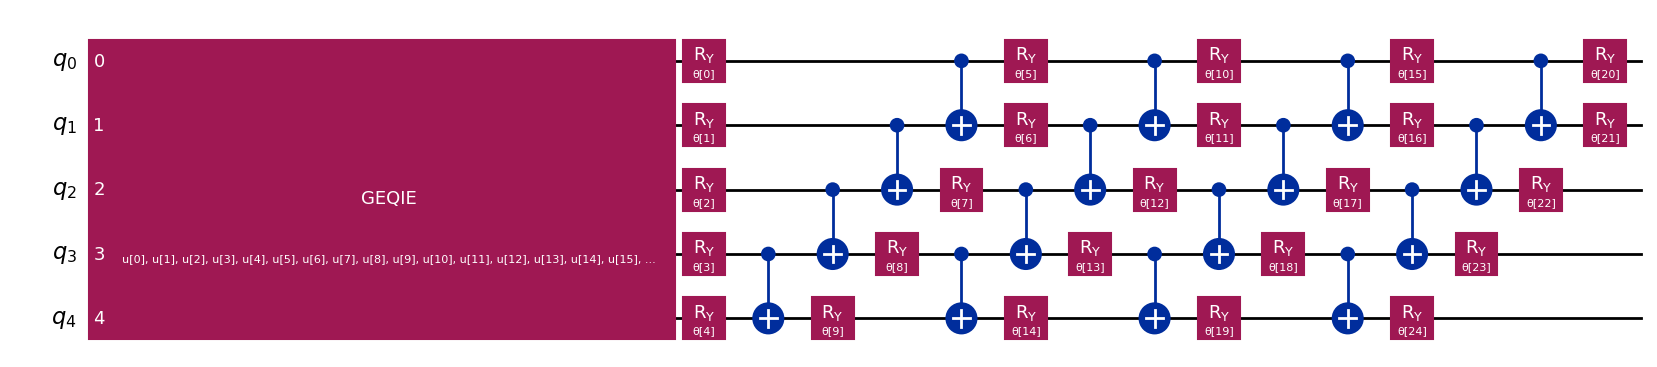

In [ ]:
pqc = qiskit.QuantumCircuit(N_QUBITS)
geqie_layer = geqie_qml.GEQIELayer(N_QUBITS)
test_ansatz = real_amplitudes(N_QUBITS, reps=N_LAYERS)

pqc.compose(geqie_layer, pqc.qubits, inplace=True)
pqc.compose(test_ansatz, pqc.qubits, inplace=True)
pqc.draw("mpl")

In [14]:
sampler = SamplerQNN(
    circuit=pqc,
    input_params=geqie_layer.parameters, 
    weight_params=test_ansatz.parameters,
    input_gradients=True,
)

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


In [ ]:
data = torch.DataLoader("data/train", batch_size=32, shuffle=True)

In [ ]:
model = nn.Sequential(
    nn.Flatten(),
    TorchConnector(sampler),
    nn.Linear(2**N_QUBITS, N_CLASSES),
    nn.LogSoftmax(dim=-1),
)

In [ ]:
for batch in data:
    output = model(batch)
    print(output)
    break

In [23]:
torchinfo.summary(model)

Layer (type:depth-idx)                   Param #
Sequential                               --
├─Flatten: 1-1                           --
├─TorchConnector: 1-2                    25
├─Linear: 1-3                            330
├─LogSoftmax: 1-4                        --
Total params: 355
Trainable params: 355
Non-trainable params: 0

In [29]:
import zipfile
with zipfile.ZipFile("../.precomputed.zip","r") as zip_data:
    print(next(iter(zip_data)))


TypeError: 'ZipFile' object is not iterable